# Най-кратък път (Shortest Path)

Отвори в Colab: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)]({{< var colabPrefix >}}06-03-Shortest-Path.ipynb)


In [1]:
#| include: false

import importlib
import importlib.util
import subprocess
import sys
from pathlib import Path

# Install gurobipy only when needed and only in Colab.
if importlib.util.find_spec("gurobipy") is None:
    if "google.colab" in sys.modules:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "gurobipy"])
    else:
        print("gurobipy is not installed. Install it in your local environment.")

# Try local import first; if missing in Colab, clone repo and import from it.
try:
    graphs = importlib.import_module("scripts.graphs")
except ModuleNotFoundError:
    if "google.colab" not in sys.modules:
        raise

    repo_url = "https://github.com/febse/opt2026.git"
    clone_dir = Path("/content/opt2026")

    if not clone_dir.exists():
        subprocess.check_call(["git", "clone", "--depth", "1", repo_url, str(clone_dir)])

    if str(clone_dir) not in sys.path:
        sys.path.insert(0, str(clone_dir))

    graphs = importlib.import_module("scripts.graphs")

print("scripts.graphs imported successfully.")

scripts.graphs imported successfully.


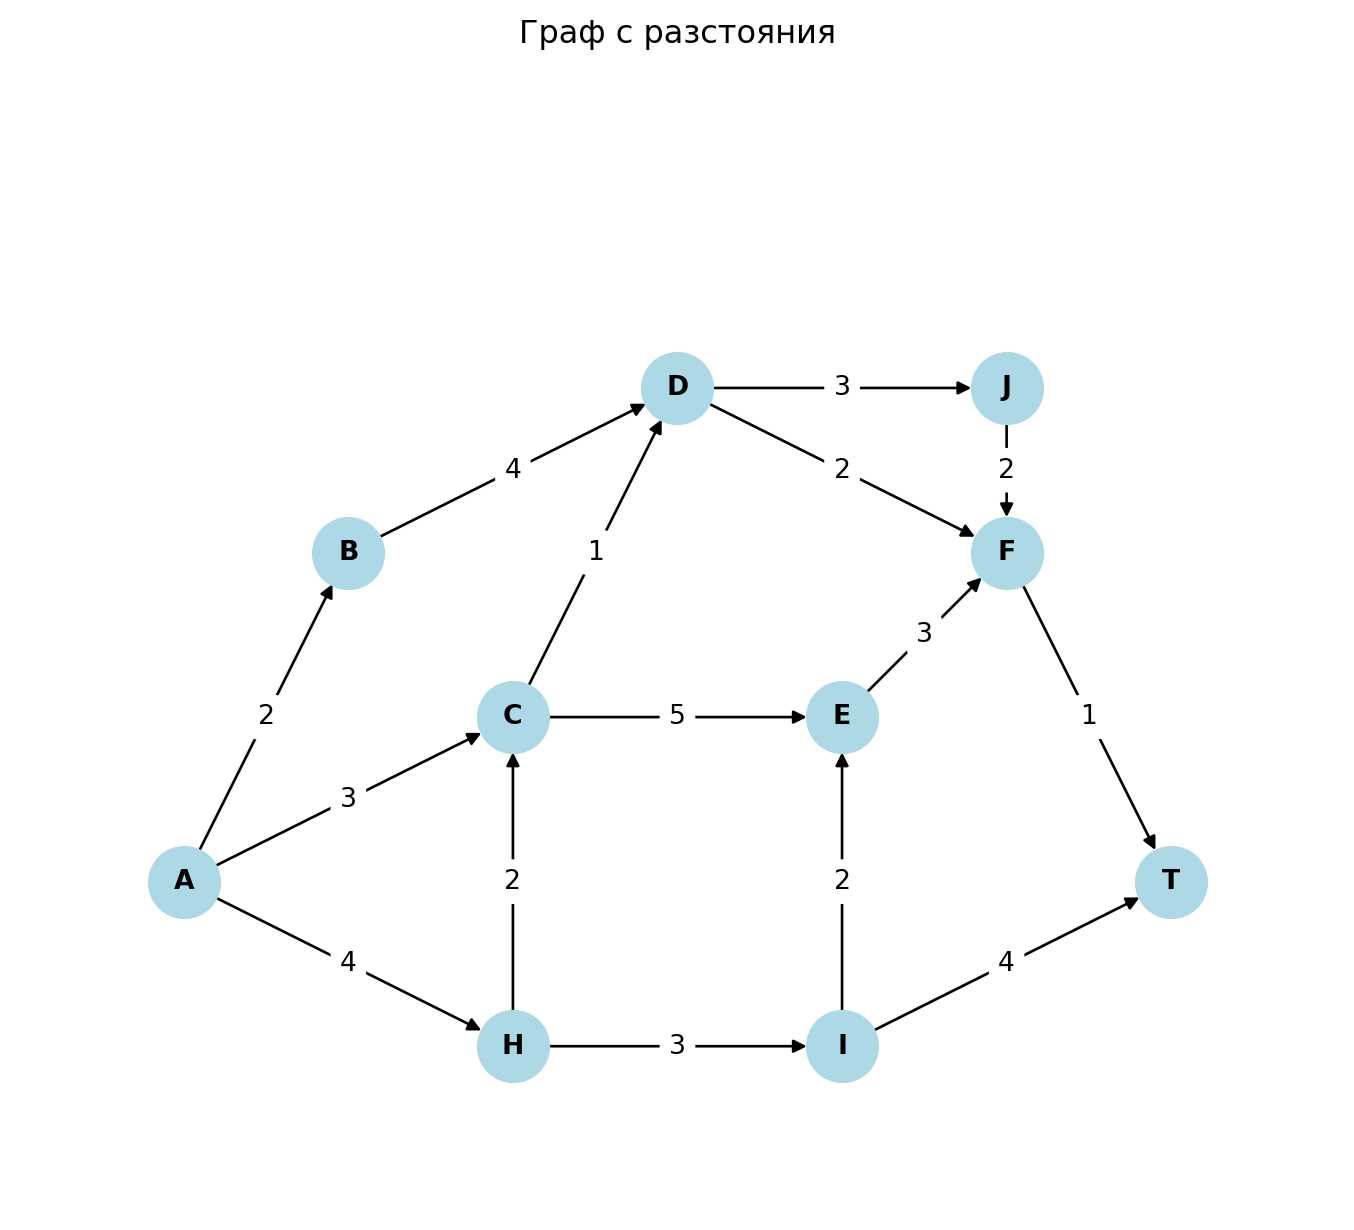

In [2]:
#| label: fig-graph-shortest-path
#| fig-cap: "Ориентирана мрежа с разстояния по дъгите."

graphs.visualize_graph("Distance", title="Граф с разстояния")

В @sec-max-flow разгледахме задача в която намерихме най-големия поток в мрежа. Настоящият проблем отново е свързан с ориентиран граф (@fig-graph-shortest-path), но този път атрибутите на дъгите представляват разстояния, например километри между градове. Целта ни е да намерим най-краткия път между $А$ (начална точка) и $Т$ (крайна точка).

- Формулирайте оптимизационна задача за намиране на най-краткия път между $А$ и $Т$. Сравнете вашия модел с този от модела в Gurobi (@sec-shortest-path-gurobi-model).
- Решете задачата с [Excel](./excel/Shortest-Path-Distances.xlsx) и сравнете резултата с този от решението с Gurobi (@sec-shortest-path-gurobi-solution)


:::{.callout-note collapse="true"}
## Решение

Целта ни в тази задача е да изберем път (множество от дъги), който свързва $А$ и $Т$ и сборът от разстояния по избраните дъги да е възможно най-малък.

Можем да формулираме проблема като използваме индикатори (бинарни променливи) за всяка дъга, които да показват дали тази дъга е част от избрания път или не. Нека да ги означим с $x_{ij}$, където $i$ и $j$ са върховете, свързани от дъгата. Тогава $x_{ij} = 1$ ако дъгата $(i,j)$ е в пътя, и $0$ иначе.

Според това какви стойности приемат тези променливи варира сумата от разстояния по избраните дъги. Нека разстоянието по дъгата $(i,j)$ е $d_{ij}$ (това са параметри на модела). Тогава общото разстояние по избрания път ще бъде:

$$
\min z = \sum_{(i,j) \in E} d_{ij} x_{ij}
$$

с променливи $x_{ij} \in \{0,1\}$ за всяка дъга $(i,j)$.

Това е кратък начин да запишем:

$$
\min z = 2x_{AB} + 3x_{AC} + 4x_{AH} + 4x_{BD} + 1x_{CD} + \ldots + 1 x_{FT} + 4 x_{IT}  
$$

Минимумът на тази функция все още не гарантира, че решението ще представлява път от $А$ до $Т$. Без допълнителни ограничения решението ще е нула за всички дъги, тъй като това е най-малката стойност, която може да приеме целевата функция. 

Първо искаме да гарантираме, че решението на модела ще включва дъга, която излиза от $А$, и дъга, която влиза в $Т$. Това може да се постигне с помощта на следните ограничения:

$$
\sum_{(i,j) \in V^-{A}} x_{ij} = 1 \quad \text{(трябва да излезе точно една дъга от $А$)}
$$

където множеството $V^-{A}$ съдържа всички дъги, които излизат от върха $А$. В нашата конкретна задача това са дъгите $(A,B)$, $(A,C)$ и $(A,H)$ или с други думи:

$$
x_{AB} + x_{AC} + x_{AH} = 1
$$

В упражнението дискутирахме, че това ограничение може да се напише и като неравенство $x_{AB} + x_{AC} + x_{AH} \geq 1$, тъй като моделът ще се стреми да минимизира целевата функция и няма да избере повече дъги, отколкото е необходимо. Експериментирайте с това в Excel и проверете дали решението се променя, ако използвате неравенство вместо равенство.

Друга дискусия от упражнението беше свързана със строги неравенства при оптимизационни проблеми. Вижте повече детайли тук: [Защо Gurobi не поддържа строги неравенства?](https://support.gurobi.com/hc/en-us/articles/360060594351-Why-doesn-t-Gurobi-support-strict-inequality-constraints-like-x-a).

$$
\sum_{(i,j) \in V^+{T}} x_{ij} = 1 \quad \text{(трябва да влезе точно една дъга в $Т$)}
$$

където множеството $V^+{T}$ съдържа всички дъги, които влизат в върха $Т$. В нашата конкретна задача това са дъгите $(F,T)$ и $(I,T)$, така че друг (по-дълъг) начин да запишем това ограничение е:

$$
x_{FT} + x_{IT} = 1
$$

С настоящите две ограничения моделът ни ще избере $x_{AB} = 1$ и $x_{FT} = 1$, за да изпълни двете ограничения, но ще остави всички други индикатори равни на нула (защото това ще е минималната стойност на дължината на пътя). Това очевидно не е валиден път от $А$ до $Т$, затова искаме да наложим допълнителни ограничения за запазване на потока (Flow Conservation) също както и в задачата за максимален поток. За всички възли, различни от $А$ и $Т$ искаме моделът да гарантира, че ако избере дъга, която влиза в този възел, то трябва да избере и дъга, която излиза от него. Например за възела $B$ ще изискаме ако $x_{AB} = 1$, то $x_{BD} = 1$ (ако пътят преминава през $B$, то трябва да продължи към $D$). Също така, ако $x_{AB} = 0$, то $x_{BD} = 0$ (ако пътят не преминава през $B$, то не може да продължи към $D$). Това може да се запише с помощта на следното ограничение:

$$
x_{AB} = x_{BD}
$$

За възел $C$ ще изискаме същото:

$$
x_{AC} + x_{HC}= x_{CE} + x_{CD}
$$

Такива ограничения трябва да наложим и за останалите възли $D$, $E$, $F$, $G$ и $H$. За да съкратим писането, тези условия могат да се запишат кратко с множествата $V^-{i}$ и $V^+{i}$, които съдържат съответно дъгите, които влизат и излизат от възела $i$:

$$
\sum_{(j,i) \in V^-{k}} x_{ji} = \sum_{(i,j) \in V^+{k}} x_{ij} \quad  \forall k \in N \setminus \{A,T\}
$$

В горната формула $N$ е множеството от всички възли в графа. 

:::

In [3]:
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

G = graphs.G
positions = graphs.positions

edges_df = pd.DataFrame(graphs.edges, columns=["Source", "Target", "Capacity", "Distance", "Probability"])
dt = edges_df.set_index(["Source", "Target"])
nodes = sorted(set(dt.index.get_level_values(0)).union(set(dt.index.get_level_values(1))))

m = gp.Model("ShortestPath")
m.params.LogToConsole = 0

# Бинарни променливи за всяка дъга (1 ако е в пътя, 0 иначе).
x = m.addVars(dt.index, vtype=GRB.BINARY, name="x")

# Цел: минимизираме общото разстояние.
distance_dict = dt["Distance"].to_dict()
m.setObjective(x.prod(distance_dict), GRB.MINIMIZE)

source, sink = "A", "T"

m.addConstr(x.sum(source, '*') == 1, name=f"LeaveFrom_{source}")
m.addConstr(x.sum('*', sink) == 1, name=f"ArriveAt_{sink}")

for node in nodes:
    if node in [source, sink]:
        continue

    inflow = x.sum('*', node)
    outflow = x.sum(node, '*')

    m.addConstr(inflow == outflow, name=f"FlowConservation_{node}")

m.optimize()

Restricted license - for non-production use only - expires 2027-11-29


Set parameter LogToConsole to value 0


## Модел в Gurobi {#sec-shortest-path-gurobi-model}

In [4]:
m.write("__shortest_path.lp")

with open("__shortest_path.lp", "r") as f:
    print(f.read())

\ Model ShortestPath
\ LP format - for model browsing. Use MPS format to capture full model detail.
Minimize
  2 x[A,B] + 3 x[A,C] + 4 x[B,D] + x[C,D] + 5 x[C,E] + 2 x[D,F] + 3 x[E,F]
   + x[F,T] + 4 x[A,H] + 2 x[H,C] + 3 x[H,I] + 2 x[I,E] + 4 x[I,T]
   + 3 x[D,J] + 2 x[J,F]
Subject To
 LeaveFrom_A: x[A,B] + x[A,C] + x[A,H] = 1
 ArriveAt_T: x[F,T] + x[I,T] = 1
 FlowConservation_B: x[A,B] - x[B,D] = 0
 FlowConservation_C: x[A,C] - x[C,D] - x[C,E] + x[H,C] = 0
 FlowConservation_D: x[B,D] + x[C,D] - x[D,F] - x[D,J] = 0
 FlowConservation_E: x[C,E] - x[E,F] + x[I,E] = 0
 FlowConservation_F: x[D,F] + x[E,F] - x[F,T] + x[J,F] = 0
 FlowConservation_H: x[A,H] - x[H,C] - x[H,I] = 0
 FlowConservation_I: x[H,I] - x[I,E] - x[I,T] = 0
 FlowConservation_J: x[D,J] - x[J,F] = 0
Bounds
Binaries
 x[A,B] x[A,C] x[B,D] x[C,D] x[C,E] x[D,F] x[E,F] x[F,T] x[A,H] x[H,C]
 x[H,I] x[I,E] x[I,T] x[D,J] x[J,F]
End



## Решение с Gurobi {#sec-shortest-path-gurobi-solution}

In [5]:
if m.status == GRB.OPTIMAL:
    selected_edges = [(u, v) for (u, v) in dt.index if x[u, v].X > 0.5]
    shortest_distance = m.objVal

    print("Намерен е най-кратък път.")
    print(f"Обща дължина: {shortest_distance}")
    print("Избрани дъги:")
    for u, v in selected_edges:
        print(f"  {u} -> {v} (Distance={distance_dict[(u, v)]})")
else:
    print("Не е намерено оптимално решение.")

Намерен е най-кратък път.
Обща дължина: 7.0
Избрани дъги:
  A -> C (Distance=3)
  C -> D (Distance=1)
  D -> F (Distance=2)
  F -> T (Distance=1)


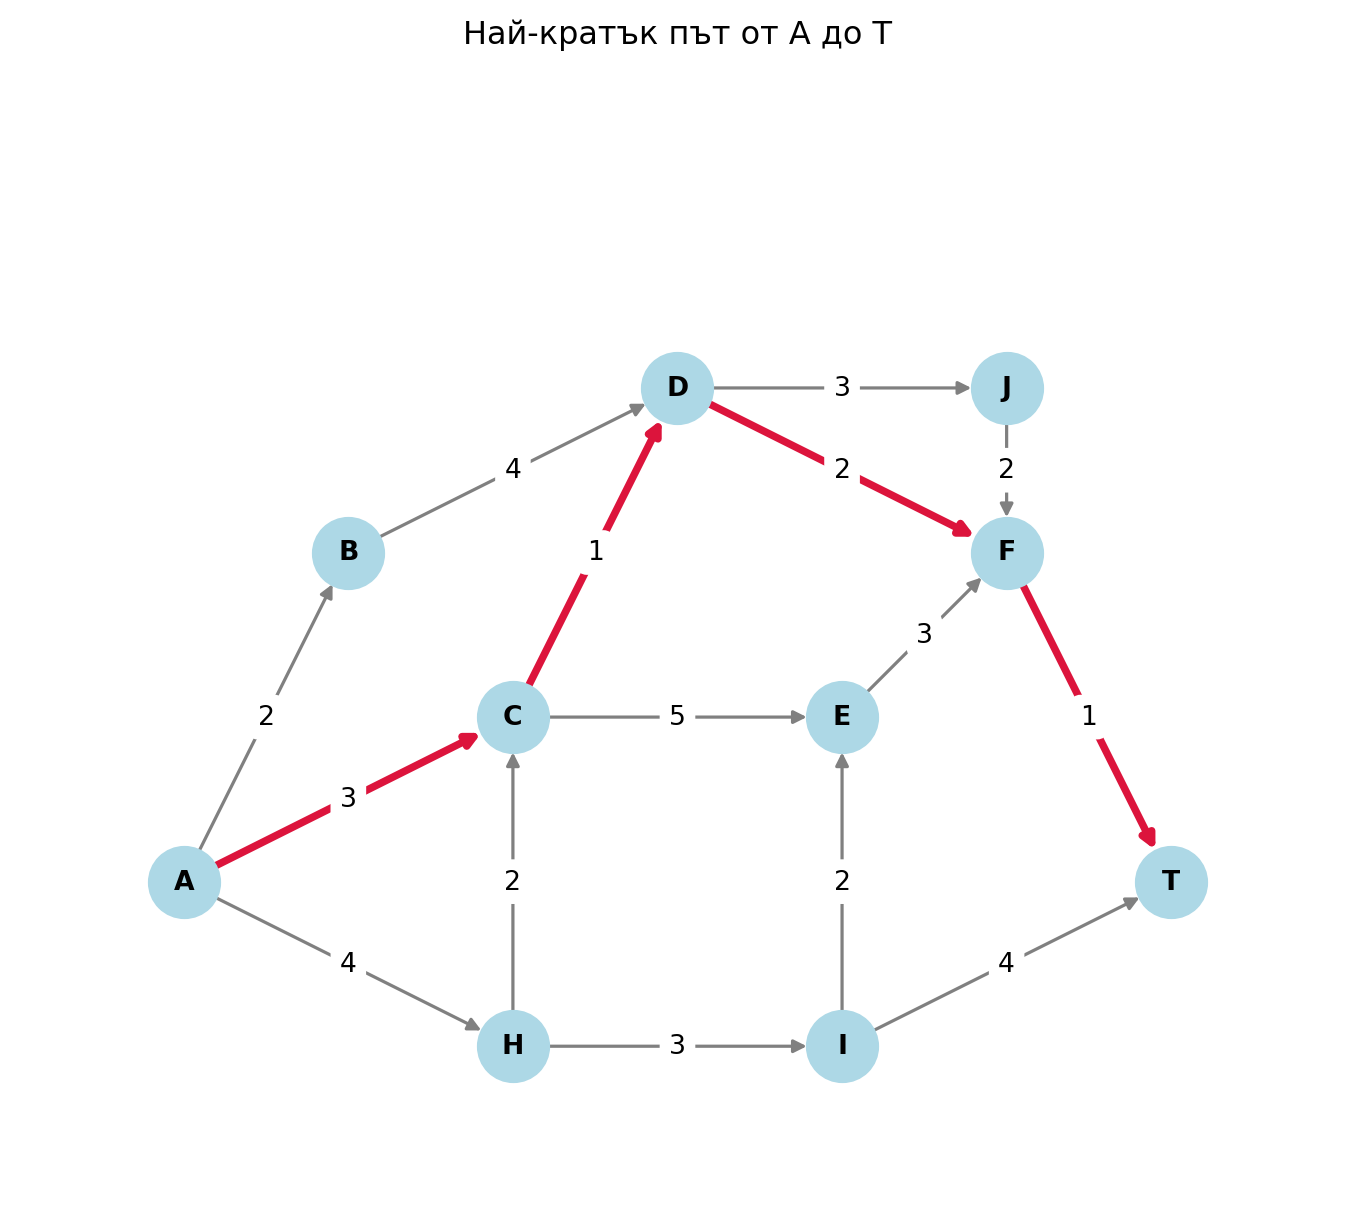

In [6]:
#| label: fig-shortest-path-optimal
#| fig-cap: "Най-краткият път от A до T е отбелязан в червено."

if m.status == GRB.OPTIMAL:
    selected_edges = {(u, v) for (u, v) in dt.index if x[u, v].X > 0.5}
    edge_colors = ["crimson" if (u, v) in selected_edges else "gray" for (u, v) in G.edges()]
    edge_widths = [2.8 if (u, v) in selected_edges else 1.2 for (u, v) in G.edges()]

    plt.figure(figsize=(8, 6))
    nx.draw(
        G,
        pos=positions,
        with_labels=True,
        node_size=700,
        node_color="lightblue",
        font_size=10,
        font_weight="bold",
        arrows=True,
        edge_color=edge_colors,
        width=edge_widths
    )

    edge_labels = nx.get_edge_attributes(G, "Distance")
    nx.draw_networkx_edge_labels(G, pos=positions, edge_labels=edge_labels, rotate=False)

    plt.xlim(-1, 7)
    plt.ylim(-2, 5)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title("Най-кратък път от A до T")
    plt.grid()
    plt.show()

In [7]:
m.write("shortest_path.lp")

with open("shortest_path.lp", "r") as file:
    print(file.read())

\ Model ShortestPath
\ LP format - for model browsing. Use MPS format to capture full model detail.
Minimize
  2 x[A,B] + 3 x[A,C] + 4 x[B,D] + x[C,D] + 5 x[C,E] + 2 x[D,F] + 3 x[E,F]
   + x[F,T] + 4 x[A,H] + 2 x[H,C] + 3 x[H,I] + 2 x[I,E] + 4 x[I,T]
   + 3 x[D,J] + 2 x[J,F]
Subject To
 LeaveFrom_A: x[A,B] + x[A,C] + x[A,H] = 1
 ArriveAt_T: x[F,T] + x[I,T] = 1
 FlowConservation_B: x[A,B] - x[B,D] = 0
 FlowConservation_C: x[A,C] - x[C,D] - x[C,E] + x[H,C] = 0
 FlowConservation_D: x[B,D] + x[C,D] - x[D,F] - x[D,J] = 0
 FlowConservation_E: x[C,E] - x[E,F] + x[I,E] = 0
 FlowConservation_F: x[D,F] + x[E,F] - x[F,T] + x[J,F] = 0
 FlowConservation_H: x[A,H] - x[H,C] - x[H,I] = 0
 FlowConservation_I: x[H,I] - x[I,E] - x[I,T] = 0
 FlowConservation_J: x[D,J] - x[J,F] = 0
Bounds
Binaries
 x[A,B] x[A,C] x[B,D] x[C,D] x[C,E] x[D,F] x[E,F] x[F,T] x[A,H] x[H,C]
 x[H,I] x[I,E] x[I,T] x[D,J] x[J,F]
End



## Упражнение: Най-безопасен път

За упражнение разгледайте графа във @fig-graph-safest-path. Също както при горната задача, графът представлява пътища между градове, но този път атрибутите на дъгите не са разстояния, а вероятности за катастрофа. Водачът иска да намери най-безопасния маршрут от $А$ до $Т$, т.е. този, при който вероятността да няма катастрофа е най-висока. Приемете, че катастрофите по отделните пътища настъпват независимо една от друга и намерете решението в [Excel](./excel/Safest-Path-Probabilities.xlsx). Каква е вероятността за катастрофа по най-безопасния маршрут?

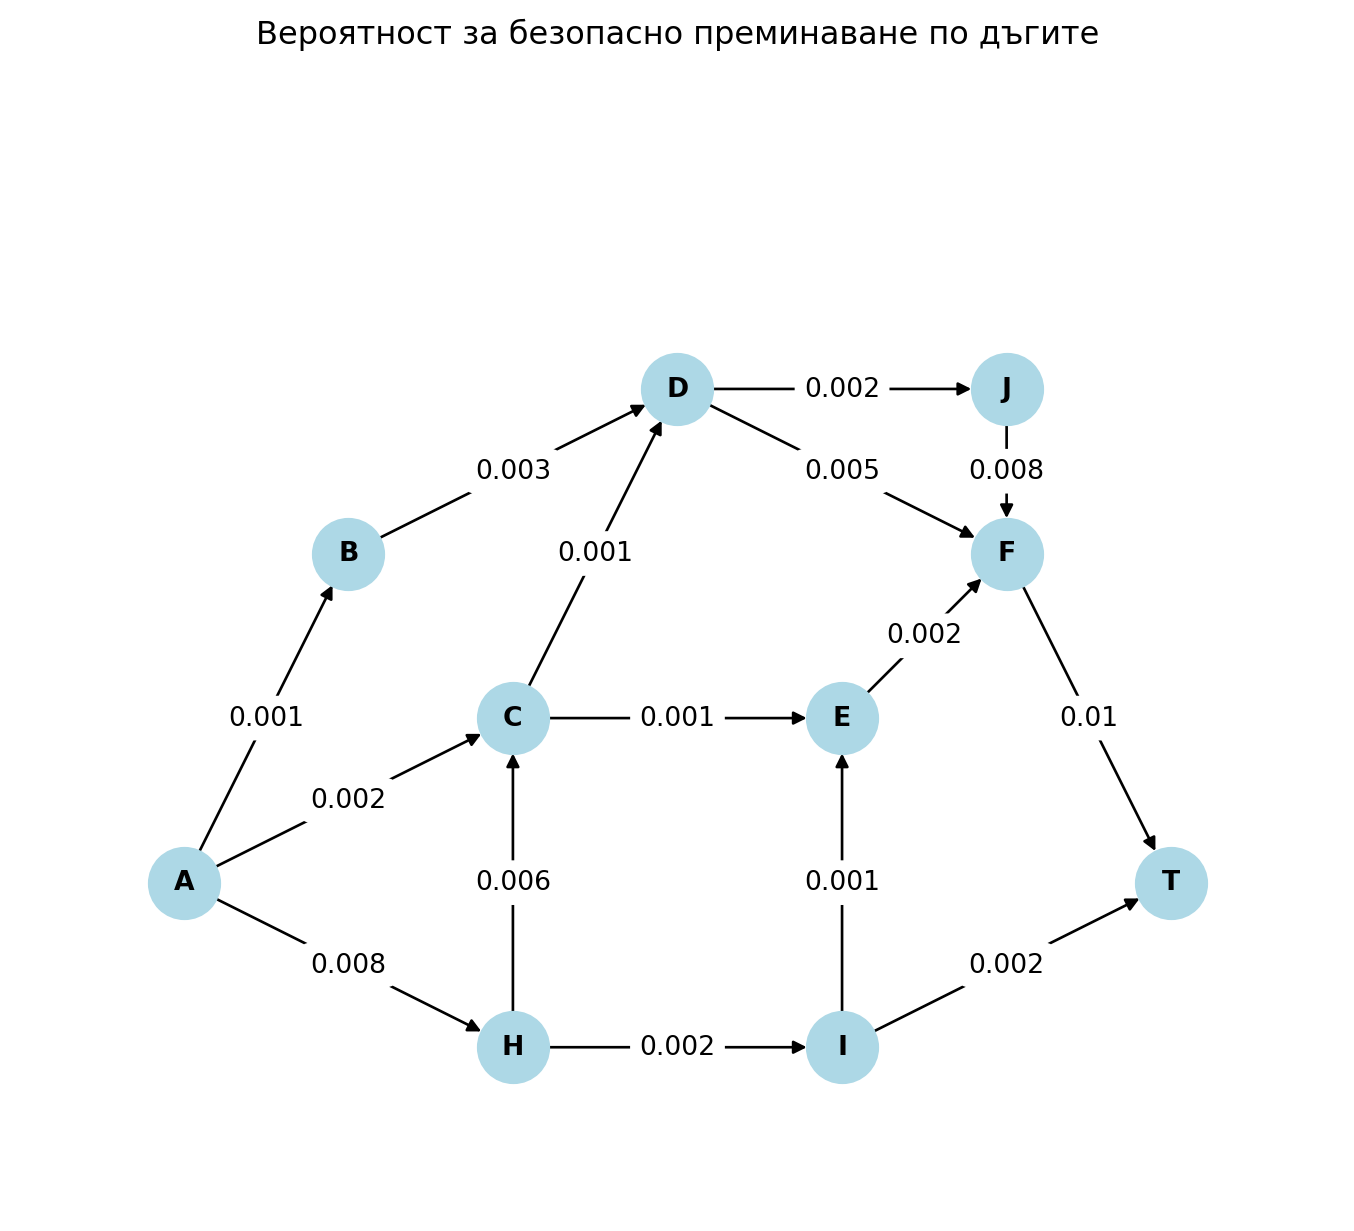

In [8]:
#| label: fig-graph-safest-path

graphs.visualize_graph("Probability", title="Вероятност за безопасно преминаване по дъгите")